In [16]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [17]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *  

In [18]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to C:\Users\Michael 
Ocampo\Documents\mini\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [19]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='PIDMYE1.tcl',
                output_file='PIDMYE1',
                prefix="ops")

In [20]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (151223261020)>


In [21]:
# Some user-defined variables
matOpt = 1  # 1 = pressure depend; 2 = pressure independ
fmass = 1.0  # fluid mass density
smass = 2.0  # saturated soil mass density
G = 6.0e4
B = 2.4e5
bulk = 2.2e6  # fluid-solid combined bulk modulus
vperm = 5.0e-4  # vertical permeability (m/s)
hperm = 5.0e-4  # horizontal permeability (m/s)
accGravity = 9.81  # acceleration of gravity

# Actual values used in computation
vperm = vperm / accGravity / fmass
hperm = hperm / accGravity / fmass

press = 0.0  # isotropic consolidation pressure on quad element(s)
loadBias = 0.07  # Static shear load, in percentage of gravity load

accMul = 2.0  # acc. multiplier
accNam = "whatever.acc"  # file name for input acc. record
accDt = 0.0166  # dt of input acc. record
period = 1.0  # Period for applied Sine wave
deltaT = 0.01  # time step for analysis
numSteps = 2400  # number of time steps
gamma = 0.6  # Newmark integration parameter

massProportionalDamping = 0.0
InitStiffnessProportionalDamping = 0.002

numXele = 1  # number of elements in x (H) direction
numYele = 10  # number of elements in y (V) direction
xSize = 1.0  # x direction element size
ySize = 1.0  # y direction element size


refshearModul = 6e4
rho = 1.8
refbulk = 3e5
frictionAngle = 30
cohesion = 30
peakShearStrain = 0.1
refPressure = 0
pressDependent = 0
noYieldSurf = 20

#############################################################
# BUILD MODEL

# create the ModelBuilder
ops.wipe()
ops.model("basic", "-ndm", 2, "-ndf", 3)

# define material and properties
if matOpt == 1:
    ops.nDMaterial("PressureDependMultiYield", 1, 2, smass, G, B, 31.4, 0.1, 80, 0.5,
                   26.5, 0.1, 0.2, 5, 10, 0.015, 1.0)
elif matOpt == 2:
    ops.nDMaterial('PressureIndependMultiYield', 2, 2, rho, refshearModul, refbulk, cohesion, peakShearStrain, frictionAngle, refPressure, pressDependent, noYieldSurf)

gravY = -accGravity  # calc. gravity
gravX = -gravY * loadBias

# define nodes
numXnode = numXele + 1
numYnode = numYele + 1

for j in range(numYnode):
    for i in range(numXnode):
        xdim = i * xSize
        ydim = j * ySize
        nodeNum = i + 1 + j * numXnode
        ops.node(nodeNum, xdim, ydim)

# define elements
for j in range(numYele):
    for i in range(numXele):
        eleNum = i + 1 + j * numXele
        n1 = i + 1 + j * numXnode
        n2 = i + 2 + j * numXnode
        n4 = i + 2 + (j + 1) * numXnode
        n3 = i + 1 + (j + 1) * numXnode

        ops.element("quadUP", eleNum, n1, n2, n4, n3, 1.0, matOpt, bulk, fmass, hperm, vperm, gravX, gravY, press)

# set material to elastic for gravity loading
ops.updateMaterialStage("-material", matOpt, "-stage", 0)

# fix the base, and free surface drainage
for i in range(1, numXnode + 1):
    ops.fix(i, 1, 1, 0)
    surfnode = numYnode * numXnode - numXnode + i
    ops.fix(surfnode, 0, 0, 1)

# tie all disp. DOFs at same level
for i in range(1, numYnode):
    nodeNum1 = i * numXnode + 1
    for j in range(2, numXnode + 1):
        nodeNum2 = i * numXnode + j
        ops.equalDOF(nodeNum1, nodeNum2, 1, 2)

#############################################################
# GRAVITY APPLICATION (elastic behavior)

# create the SOE, ConstraintHandler, Integrator, Algorithm and Numberer
ops.numberer("RCM")
ops.system("ProfileSPD")
ops.test("NormDispIncr", 1.0e-8, 25, 2)
ops.algorithm("Newton")
ops.constraints("Penalty", 1.0e18, 1.0e18)
ops.integrator("Newmark", 1.5, 1.0)
ops.analysis("Transient")

ops.analyze(3, 5.0e3)



CTestNormDispIncr::test() - iteration: 6 current Norm: 3.63266e-10 (max: 1e-08, Norm deltaR: 1.02014)
CTestNormDispIncr::test() - iteration: 5 current Norm: 2.69937e-09 (max: 1e-08, Norm deltaR: 0.425652)
CTestNormDispIncr::test() - iteration: 4 current Norm: 7.38187e-09 (max: 1e-08, Norm deltaR: 1.07464)


0

In [22]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [23]:
# switch material stage from elastic (gravity) to plastic
ops.updateMaterialStage("-material", matOpt, "-stage", 1)
ops.analyze(5, 5.0e3)

# rezero time
ops.wipeAnalysis()
ops.setTime(0.0)

#############################################################
# NOW APPLY LOADING SEQUENCE AND ANALYZE (plastic)

# base input motion
ops.timeSeries('Sine', 1, 0.0, 10.0, period, "-factor", accMul)
ops.pattern("UniformExcitation", 1, 1, "-accel",1)

# recorder for nodal variables along the vertical center line.
nodeList = []
# The Tcl code has a bug where numXnode/2 would be integer division.
# In Python, this is float division, so we need to fix it.
# We'll assume the intent was to get the node at the center of the x-axis.
center_node_x = int(numXnode / 2)
for i in range(numYnode):
    nodeList.append(center_node_x + i * numXnode)

# define recorders for disp., excess pore pressure, and acc.
ops.recorder("Node", "-file", "disp", "-time", "-node", *nodeList, "-dof", 1, 2, "-dT", deltaT, "disp")
ops.recorder("Node", "-file", "pwp", "-time", "-node", *nodeList, "-dof", 3, "-dT", deltaT, "vel")
ops.recorder("Node", "-file", "acc", "-time", "-node", *nodeList, "-dof", 1, 2, "-dT", deltaT, "accel")

# stress/strain output at Gauss point 1 of each element along center line
name1 = "stress"
name2 = "strain"
# The Tcl code also had a potential issue with integer division here
center_ele_x = int(numXele / 2)
for i in range(1, numYnode):
    ele = center_ele_x + (i - 1) * numXele
    name11 = f"{name1}{i}"
    name21 = f"{name2}{i}"
    ops.recorder("Element", "-ele", ele, "-time", "-file", name11, "-dT", deltaT, "material", 1, "stress")
    ops.recorder("Element", "-ele", ele, "-time", "-file", name21, "-dT", deltaT, "material", 1, "strain")

# analysis options
ops.constraints("Penalty", 1.0e18, 1.0e18)
ops.test("NormDispIncr", 1.0e-5, 25, 0)
ops.numberer("RCM")
ops.algorithm("Newton")
ops.system("ProfileSPD")

# some mass proportional and initial-stiffness proportional damping
ops.rayleigh(massProportionalDamping, 0.0, InitStiffnessProportionalDamping, 0.0)
ops.integrator("Newmark", gamma, np.power(gamma + 0.5, 2) / 4)
ops.analysis("VariableTransient")

# analyze
startT = tt.time()
ops.analyze(numSteps, deltaT, deltaT / 100, deltaT, 15)
endT = tt.time()

print(f"Execution time: {endT - startT} seconds.")

ops.wipe()

CTestNormDispIncr::test() - iteration: 19 current Norm: 7.32742e-09 (max: 1e-08, Norm deltaR: 0.813703)
CTestNormDispIncr::test() - iteration: 17 current Norm: 6.66076e-09 (max: 1e-08, Norm deltaR: 0.835392)
CTestNormDispIncr::test() - iteration: 16 current Norm: 6.94239e-09 (max: 1e-08, Norm deltaR: 0.750197)
CTestNormDispIncr::test() - iteration: 15 current Norm: 4.99861e-09 (max: 1e-08, Norm deltaR: 0.612832)
CTestNormDispIncr::test() - iteration: 13 current Norm: 6.91512e-09 (max: 1e-08, Norm deltaR: 0.888203)
after: 25 iterations  current Norm: 0.000212546 (max: 1e-05, Norm deltaR: 0.662196)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 1.18587e-05 (max: 1e-05, Norm deltaR: 34.5789)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 0.000708552 (max: 1e-05, Norm deltaR: 47.2167)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in 

Execution time: 4.591525316238403 seconds.


after: 25 iterations  current Norm: 0.00024202 (max: 1e-05, Norm deltaR: 372.899)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()


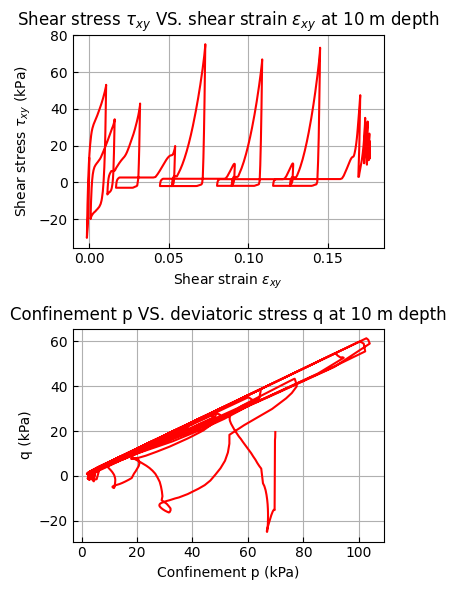

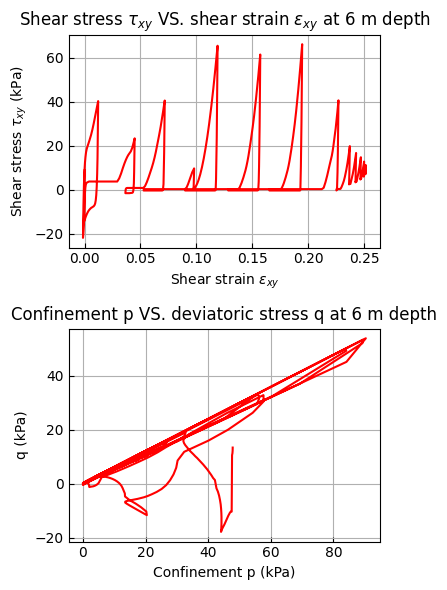

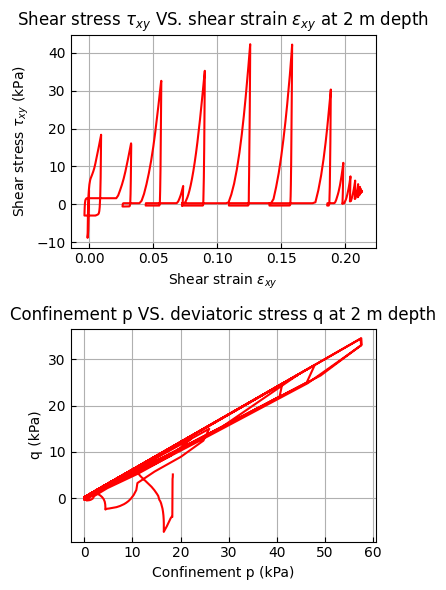

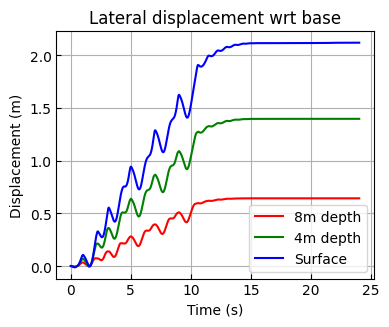

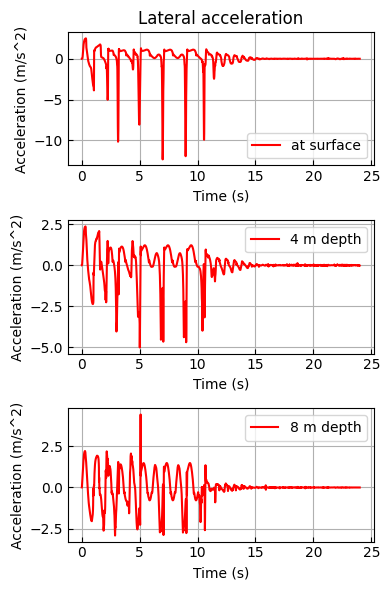

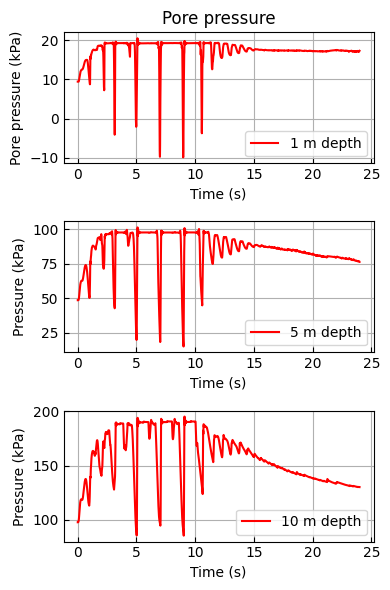

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load the data from files ---
# In Python, we typically use numpy.loadtxt for text files,
# assuming they are space or comma-separated.
# The `unpack=True` argument can be used to unpack the columns into separate variables,
# but we'll stick to loading the full matrix for clarity.
a1 = np.loadtxt('acc')
d1 = np.loadtxt('disp')
p1 = np.loadtxt('pwp')
s1 = np.loadtxt('stress2')
e1 = np.loadtxt('strain2')
s5 = np.loadtxt('stress5')
e5 = np.loadtxt('strain5')
s9 = np.loadtxt('stress9')
e9 = np.loadtxt('strain9')

# Define global variables
fs = [0.5, 0.2, 4, 6]  # [left, bottom, width, height] for paperposition
accMul = 2

# --- 2. Helper function for p-q calculations and plotting ---
# This function helps to avoid repeating the same plotting code.
def plot_stress_strain_and_pq(stress_data, strain_data, figure_num, depth, filename):
    """
    Plots the shear stress vs. shear strain and confinement vs. deviatoric stress.

    Parameters:
    - stress_data (np.ndarray): The stress data matrix.
    - strain_data (np.ndarray): The strain data matrix.
    - figure_num (int): The figure number for the plot.
    - depth (str): A string representing the depth for the plot titles.
    - filename (str): The base name for saving the figure.
    """
    # Calculate p (mean normal stress)
    po = (stress_data[:, 1] + stress_data[:, 2] + stress_data[:, 3]) / 3.0

    # Calculate q (deviatoric stress)
    # The MATLAB code uses a loop, but we can do this with a single
    # vectorized operation in NumPy, which is much more efficient.
    term1 = (stress_data[:, 1] - stress_data[:, 2])**2
    term2 = (stress_data[:, 2] - stress_data[:, 3])**2
    term3 = (stress_data[:, 1] - stress_data[:, 3])**2
    term4 = 6.0 * stress_data[:, 4]**2
    qo = np.sqrt(term1 + term2 + term3 + term4) / 3.0
    
    # Apply the sign of s_xy (stress_data[:, 4]) to qo
    qo = np.sign(stress_data[:, 4]) * qo

    # Create the figure and subplots
    plt.figure(figure_num, figsize=(fs[2], fs[3])) # The 'figsize' parameter replaces MATLAB's 'paperposition'
    plt.clf()  # Clear the current figure before plotting
    
    # Subplot 1: Shear stress vs. shear strain
    plt.subplot(2, 1, 1)
    plt.plot(strain_data[:, 3], stress_data[:, 4], 'r')
    plt.title(f'Shear stress $\\tau_{{xy}}$ VS. shear strain $\\epsilon_{{xy}}$ at {depth} depth')
    plt.xlabel('Shear strain $\\epsilon_{{xy}}$')
    plt.ylabel('Shear stress $\\tau_{{xy}}$ (kPa)')
    plt.grid(True)

    # Subplot 2: Confinement vs. deviatoric stress
    plt.subplot(2, 1, 2)
    plt.plot(-po, qo, 'r')
    plt.title(f'Confinement p VS. deviatoric stress q at {depth} depth')
    plt.xlabel('Confinement p (kPa)')
    plt.ylabel('q (kPa)')
    plt.grid(True)
    
    plt.tight_layout() # Adjusts subplot parameters for a tight layout
    
    # Save the figure
    plt.savefig(f'{filename}.jpg', dpi=300)

# --- 3. Plotting the data for different integration points ---
# Call the helper function for each integration point
plot_stress_strain_and_pq(s1, e1, 1, '10 m', 'SS_PQ_10m')
plot_stress_strain_and_pq(s5, e5, 5, '6 m', 'SS_PQ_6m')
plot_stress_strain_and_pq(s9, e9, 6, '2 m', 'SS_PQ_2m')

# --- 4. Plotting displacement data ---
plt.figure(2, figsize=(fs[2], fs[3]))
plt.clf()
plt.subplot(2, 1, 1)
plt.plot(d1[:, 0], d1[:, 7], 'r', label='8m depth')
plt.plot(d1[:, 0], d1[:, 13], 'g', label='4m depth')
plt.plot(d1[:, 0], d1[:, 21], 'b', label='Surface')
plt.title('Lateral displacement wrt base')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (m)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('Disp.jpg', dpi=300)

# --- 5. Plotting acceleration data ---
plt.figure(3, figsize=(fs[2], fs[3]))
plt.clf()

# Interpolate the sine wave
# MATLAB's interp1 is similar to scipy.interpolate.interp1d, but we can
# also manually create the sine wave and use numpy's interpolation function.
# Here, we'll replicate the MATLAB logic with NumPy.
t_sine = np.arange(0, 40.01, 0.01) # a1(:,1) is time, let's assume it starts at 0
s_wave = accMul * np.sin(np.arange(0, 20*np.pi + 1e-9, np.pi/50))
s_padded = np.pad(s_wave, (0, 3000), 'constant')
s_interpolated = np.interp(a1[:, 0], t_sine[:len(s_padded)], s_padded)

# Subplot 1: Surface acceleration
plt.subplot(3, 1, 1)
plt.plot(a1[:, 0], s_interpolated + a1[:, 21], 'r', label='at surface')
plt.title('Lateral acceleration')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)

# Subplot 2: 4 m depth acceleration
plt.subplot(3, 1, 2)
plt.plot(a1[:, 0], s_interpolated + a1[:, 13], 'r', label='4 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)

# Subplot 3: 8 m depth acceleration
plt.subplot(3, 1, 3)
plt.plot(a1[:, 0], s_interpolated + a1[:, 7], 'r', label='8 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Acceleration (m/s^2)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('Acc.jpg', dpi=300)


# --- 6. Plotting pore pressure data ---
plt.figure(4, figsize=(fs[2], fs[3]))
plt.clf()

# Subplot 1: 1 m depth
plt.subplot(3, 1, 1)
plt.plot(p1[:, 0], p1[:, 10], 'r', label='1 m depth')
plt.title('Pore pressure')
plt.xlabel('Time (s)')
plt.ylabel('Pore pressure (kPa)')
plt.legend()
plt.grid(True)

# Subplot 2: 5 m depth
plt.subplot(3, 1, 2)
plt.plot(p1[:, 0], p1[:, 6], 'r', label='5 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (kPa)')
plt.legend()
plt.grid(True)

# Subplot 3: 10 m depth
plt.subplot(3, 1, 3)
plt.plot(p1[:, 0], p1[:, 1], 'r', label='10 m depth')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (kPa)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('EPWP.jpg', dpi=300)

plt.show() # Display all generated plots